# Retrocausality Mini Project

**当前规模**：3 agents, 5×5 grid, 7 steps, Mesa 2.3.0, PyTorch TCN-based

目标：  
Agent 0 使用 TCN 预测未来碰撞 → 实时调整当前移动，避免碰撞；  
其他两个 agent 随机移动（allow_collisions=True 时倾向碰撞）。

主要功能：
- 生成混合数据（易碰撞 + 难碰撞）
- 训练 / 加载 TCN
- 对比：纯随机 vs 有 TCN 规则 的碰撞次数

In [20]:
import torch
import gc

# 强制全局使用 CPU（RTX 5070 sm_120 当前环境不兼容）
device = torch.device('cpu')
torch.set_default_device(device)   # PyTorch 2.1+ 支持
print(f"⚠️ 强制使用 CPU 模式 | device = {device}")

# 清理可能残留的 CUDA 缓存
if torch.cuda.is_available():
    torch.cuda.empty_cache()
gc.collect()

⚠️ 强制使用 CPU 模式 | device = cpu


2727

In [2]:
# ==============================================
# 导入（只保留当前 mini 项目真正需要的）
# ==============================================
import random
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pickle
from tqdm import tqdm

# Mesa（已固定版本 2.3.0）
from mesa import Agent, Model
from mesa.space import MultiGrid
from mesa.time import RandomActivation

# ====================== 项目配置与模块 ======================
# 先设置工作目录（放在最前面，避免路径问题）
# 在 Jupyter notebook 中获取项目根目录
# notebook 在 notebooks/ 子目录中，需要上升一级
import os
import sys
from pathlib import Path

current_dir = Path.cwd()
project_root = current_dir.parent if current_dir.name == 'notebooks' else current_dir
os.chdir(project_root)

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print(f"工作目录已设置为: {os.getcwd()}")

# ================== 导入 config（必须在最前面） ==================
from config import *

# ================== 导入项目核心模块（暂不导入会被重新加载的类） ==================
# ⚠️ 注意：不在这里导入具体的类（如TCN, RetroModel等），因为后面会重新加载
# 改为导入模块本身
import src.model
import src.tcn
import src.data_gen
from src.visualize import create_animation

# ====================== 固定随机种子 ======================
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
torch.backends.cudnn.deterministic = True

print("✅ 导入完成！")
print(f"   GRID: {GRID_WIDTH}x{GRID_HEIGHT}, Agents: {NUM_AGENTS}, Steps: {STEPS}")
print(f"   TCN Model Path: {TCN_MODEL_PATH}")
print(f"   Data Path: {MIXED_DATA_PATH}")

工作目录已设置为: e:\projects\Dynamic-Retrocausal-Simulator
BASE_DIR resolved to: E:\projects\Dynamic-Retrocausal-Simulator
DATA_DIR       : E:\projects\Dynamic-Retrocausal-Simulator\data
MIXED_DATA_PATH: E:\projects\Dynamic-Retrocausal-Simulator\data\abm_mixed_3agents_5x5_collisions.pkl
TCN_MODEL_PATH : E:\projects\Dynamic-Retrocausal-Simulator\models\tcn_best.pt
Current working dir: e:\projects\Dynamic-Retrocausal-Simulator
✅ 导入完成！
   GRID: 5x5, Agents: 3, Steps: 7
   TCN Model Path: E:\projects\Dynamic-Retrocausal-Simulator\models\tcn_best.pt
   Data Path: E:\projects\Dynamic-Retrocausal-Simulator\data\abm_mixed_3agents_5x5_collisions.pkl


In [ ]:
import mesa
import torch
import pandas as pd
import tqdm
print(mesa.__version__)          # 2.3.0
print(torch.__version__)         # 2.7.0
print(pd.__version__)            # 3.0.1
print(tqdm.__version__)          # 4.67.3
print("STEPS:", STEPS)                # 7
print("SEQ_LEN:", SEQ_LEN)            # 5
print("device:", device)              # cuda

## 1. 生成小规模测试数据（调试用）

In [3]:
# ==============================================
# 2. 生成小规模训练数据（调试用）
# ==============================================
# ⚠️ 重新加载 module 以确保使用最新的代码
import importlib
importlib.reload(src.model)
importlib.reload(src.data_gen)

from src.data_gen import generate_data
import pathlib

print("🚀 开始生成小批量混合训练数据...")

# 小批量参数（快速测试用，正式训练再调大）
small_data = generate_data(
    num_runs=1200,
    steps_per_run=STEPS,
    filename=MIXED_DATA_PATH,
    collision_boost=True
)

# 简单统计碰撞情况
total_collisions = 0
total_steps = 0

for run in small_data:
    for record in run:
        if record.get('collision', 0) == 1:
            total_collisions += 1
        total_steps += 1

collision_rate = total_collisions / total_steps if total_steps > 0 else 0

print(f"✅ 小批量数据生成完成！")
print(f"   生成 runs: {len(small_data)}")
print(f"   总数据点: {total_steps}")
print(f"   总碰撞次数: {total_collisions}")
print(f"   碰撞率: {collision_rate:.4f} ({collision_rate*100:.2f}%)")
print(f"   数据已保存到: {MIXED_DATA_PATH}")

# 可选：查看前几个数据样本
print("\n前3条数据示例（Agent 0）:")
agent0_samples = [d for d in small_data[0] if d['agent_id'] == 0][:3]
for sample in agent0_samples:
    print(sample)

🚀 开始生成小批量混合训练数据...
🚀 开始生成 1200 runs 数据...


Generating: 100%|██████████| 1200/1200 [00:00<00:00, 1929.16it/s]


✅ 数据生成完成！
   Total runs: 1200
   Total data points: 25200
   Total collisions (Agent 0): 706
   Collision rate: 0.0280 (2.80%)
✅ 小批量数据生成完成！
   生成 runs: 1200
   总数据点: 25200
   总碰撞次数: 1975
   碰撞率: 0.0784 (7.84%)
   数据已保存到: E:\projects\Dynamic-Retrocausal-Simulator\data\abm_mixed_3agents_5x5_collisions.pkl

前3条数据示例（Agent 0）:
{'agent_id': 0, 'pos': (0, 2), 'rel_pos': [1, -1, 1, -2, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], 'collision': 0, 'step': 0}
{'agent_id': 0, 'pos': (0, 3), 'rel_pos': [1, -2, 1, -3, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], 'collision': 0, 'step': 1}
{'agent_id': 0, 'pos': (1, 3), 'rel_pos': [0, -1, 0, -2, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], 'collision': 0, 'step': 2}


In [ ]:
# 调试：检查一个单独的 run 的数据结构
print("🔍 调试单个 run 的数据...")

# 重新加载 generate_data
import importlib
import src.data_gen
importlib.reload(src.data_gen)
from src.data_gen import generate_data

# 创建一个只有1个run的数据（使用临时文本文件）
debug_data = generate_data(
    num_runs=1,
    steps_per_run=STEPS,
    filename="./debug_data.pkl",
    collision_boost=True
)

print(f"生成的 run 数: {len(debug_data)}")
if debug_data:
    first_run = debug_data[0]
    print(f"第一个 run 的数据点数: {len(first_run)}")
    if first_run:
        print(f"第一条数据: {first_run[0]}")
    else:
        print("⚠️ 第一个 run 是空的！")
else:
    print("⚠️ debug_data 是空的！")

In [ ]:
# 快速测试：逐步验证修复
import importlib
importlib.reload(src.model)
from src.model import RetroModel, RetroAgent
import mesa

print("🔍 详细调试 Model 初始化...")

# 1. 检查 NUM_AGENTS 的值
print(f"1️⃣ NUM_AGENTS = {NUM_AGENTS}")

# 2. 手动创建 model
print(f"2️⃣ 创建 RetroModel...")
test_model = RetroModel(allow_collisions=True, num_agents=NUM_AGENTS)
print(f"   Model 创建完成")

# 3. 检查 schedule
print(f"3️⃣ 检查 schedule:")
print(f"   schedule type: {type(test_model.schedule)}")
print(f"   schedule.agents type: {type(test_model.schedule.agents)}")
print(f"   schedule.agents 长度: {len(test_model.schedule.agents)}")

# 4. 尝试手动添加agent
print(f"4️⃣ 尝试手动添加 agent:")
test_agent = RetroAgent(99, test_model, allow_collisions=True)
test_model.grid.place_agent(test_agent, (1, 1))
print(f"   agents 在place_agent后: {len(test_model.schedule.agents)}")
test_model.schedule.add(test_agent)
print(f"   agents 在schedule.add后: {len(test_model.schedule.agents)}")
print(f"   agent list: {list(test_model.schedule.agents)}")

In [15]:
# ==============================================
# 3. 训练 TCN 模型（核心步骤）
# ==============================================
# ⚠️ 重新加载顺序很重要：先model后tcn，确保tcn获取新的TCN类
import importlib
importlib.reload(src.model)            # 先重新加载src.model
importlib.reload(src.tcn)              # 再重新加载src.tcn，这样它会导入新的TCN

from src.tcn import train

print("🚀 开始训练 TCN 模型...") 
train()

🚀 开始训练 TCN 模型...
✅ Loaded 1200 runs
Processing 1200 runs for Agent 0...
Generated 2400 training sequences from Agent 0 (total_sequences=2400)
Training samples: 2,400 | Positive rate: 0.0938 (225 collisions)

🚀 Starting TCN Training - Retrocausal Collision Predictor
-------------------------------------------------------------------------------------
Epoch Train Loss   Val Acc    Val Recall   Best Acc   Best Recall  Status
-------------------------------------------------------------------------------------
1     2.0515       0.3104     0.9556       0.3104     0.9556       ★ Saved
2     1.9547       0.4521     0.8889       0.4521     0.9556       ★ Saved
3     1.9264       0.5042     0.8444       0.5042     0.9556       ★ Saved
4     1.9091       0.5292     0.8000       0.5292     0.9556       ★ Saved
5     1.8702       0.5500     0.8000       0.5500     0.9556       ★ Saved
6     1.8820       0.5625     0.8222       0.5625     0.9556       ★ Saved
7     1.8696       0.6125     0.7556  

## 2. 检查单次模拟轨迹（调试用）

In [5]:
# 手动跑一次模拟，看 Agent 0 是否使用了 TCN 规则
import importlib
importlib.reload(src.model)
from src.model import RetroModel

model = RetroModel(allow_collisions=True, tcn_path="models/tcn_best.pth")
data, coll_count = model.run_simulation(steps=7)

print(f"本次模拟 Agent 0 碰撞次数：{coll_count}")

# 打印 Agent 0 的移动序列
agent0_moves = [d['pos'] for d in data if d['agent_id'] == 0]
print("Agent 0 位置序列：", agent0_moves)

本次模拟 Agent 0 碰撞次数：2
Agent 0 位置序列： [(4, 0), (4, 0), (4, 0), (3, 0), (3, 1), (2, 1), (2, 2)]


## 3. 对比实验（核心验证 retrocausality）

In [18]:
# ==============================================
# 强制清理 + 重新加载（解决 history 属性问题）
# ==============================================
import importlib
import gc

# 清理旧对象
gc.collect()

# 强制重新加载所有相关模块
importlib.reload(src.model)
importlib.reload(src.tcn)
importlib.reload(src.data_gen)

from src.model import RetroModel, RetroAgent
from src.tcn import train   # 如果需要

print("✅ 所有模块已重新加载，RetroAgent 已带 history 属性")
print(f"   当前 device: {device}")

✅ 所有模块已重新加载，RetroAgent 已带 history 属性
   当前 device: cpu


In [21]:
# ==============================================
# 对比实验函数（compare_rule_effects） - 专为当前 mini 项目实现
# ==============================================
import importlib
importlib.reload(src.model)   # 确保使用最新 RetroModel

from src.model import RetroModel
import numpy as np
from tqdm import tqdm

def compare_rule_effects(num_sims=50, steps=STEPS, tcn_path="models/tcn_best.pth"):
    """对比：无 TCN（纯随机，allow_collisions=True） vs 有 TCN 的碰撞次数（仅统计 Agent 0）"""
    print(f"🚀 开始对比实验: {num_sims} 次模拟 × {steps} steps")
    
    coll_no_rule = 0
    coll_with_rule = 0
    
    for i in tqdm(range(num_sims), desc="Simulating"):
        # 1. 无规则（纯随机）
        model_no = RetroModel(allow_collisions=True, tcn_path=None, 
                              width=GRID_WIDTH, height=GRID_HEIGHT, num_agents=NUM_AGENTS)
        _, coll_no = model_no.run_simulation(steps=steps)
        coll_no_rule += coll_no
        
        # 2. 有 TCN 规则（Agent 0 使用 retrocausal 预测）
        model_yes = RetroModel(allow_collisions=True, tcn_path=tcn_path, 
                               width=GRID_WIDTH, height=GRID_HEIGHT, num_agents=NUM_AGENTS)
        _, coll_yes = model_yes.run_simulation(steps=steps)
        coll_with_rule += coll_yes
    
    avg_no = coll_no_rule / num_sims
    avg_yes = coll_with_rule / num_sims
    reduction = (avg_no - avg_yes) / avg_no * 100 if avg_no > 0 else 0
    
    print(f"\n✅ 对比完成！")
    print(f"   无 TCN 规则平均碰撞 (Agent 0): {avg_no:.2f}")
    print(f"   有 TCN 规则平均碰撞 (Agent 0): {avg_yes:.2f}")
    print(f"   碰撞减少比例: {reduction:.1f}%")
    
    return avg_no, avg_yes

# 现在可以安全调用了
no_rule_coll, with_rule_coll = compare_rule_effects(
    num_sims=100,
    steps=STEPS,
    tcn_path="models/tcn_best.pt"   # 改成你实际保存的 .pt 或 .pth 路径
)

reduction = (no_rule_coll - with_rule_coll) / no_rule_coll * 100 if no_rule_coll > 0 else 0
print(f"\n碰撞减少比例：{reduction:.1f}%")

🚀 开始对比实验: 100 次模拟 × 7 steps


Simulating:  10%|█         | 10/100 [00:00<00:00, 98.83it/s]

✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt


Simulating:  32%|███▏      | 32/100 [00:00<00:00, 102.83it/s]

✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt


...

✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt


Simulating:  76%|███████▌  | 76/100 [00:00<00:00, 100.35it/s]

✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt


Simulating: 100%|██████████| 100/100 [00:00<00:00, 102.09it/s]

✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt
✅ TCN 模型已加载到 CPU: models/tcn_best.pt

✅ 对比完成！
   无 TCN 规则平均碰撞 (Agent 0): 0.44
   有 TCN 规则平均碰撞 (Agent 0): 0.28
   碰撞减少比例: 36.4%

碰撞减少比例：36.4%


## 4. 快速检查 TCN 预测（调试模型）

In [ ]:
# ==============================================
# 4. 快速检查 TCN 预测（调试模型）——最终修复版
# ==============================================
import importlib
importlib.reload(src.model)
importlib.reload(src.tcn)

from src.model import TCN
from config import *   # 包含 device, SEQ_LEN, TCN_INPUT_SIZE 等

print("🔍 TCN 单条预测调试（已修复形状 + 强制 CPU）")

# 强制 CPU（RTX 5070 兼容问题）
device = torch.device('cpu')
print(f"   使用设备: {device}")

def load_tcn(model_path):
    model = TCN(
        input_size=TCN_INPUT_SIZE,      # 应该是 12
        num_channels=TCN_NUM_CHANNELS,
        kernel_size=TCN_KERNEL_SIZE,
        output_size=TCN_OUTPUT_SIZE
    )
    try:
        state_dict = torch.load(model_path, map_location=device)
        model.load_state_dict(state_dict)
        model.to(device)
        model.eval()
        print(f"✅ 模型加载成功: {model_path}")
        print(f"   模型期望输入 channels: {TCN_INPUT_SIZE}")
        return model
    except Exception as e:
        print(f"❌ 加载失败: {e}")
        return None

tcn = load_tcn("models/tcn_best.pt")   # 如果是 tcn_best.pt 就改成 .pt

if tcn is None:
    print("请确认 models/tcn_best.pt 存在且是从 train() 保存的")
else:
    # 关键修复：构造 [batch, channels=12, seq_len=5]
    # 先创建 [batch, seq_len, features] 再转置
    dummy = torch.randn(1, SEQ_LEN, TCN_INPUT_SIZE, dtype=torch.float32)
    dummy_input = dummy.permute(0, 2, 1).to(device)   # → [1, 12, 5]
    
    print(f"   输入形状 (修复后): {dummy_input.shape}  [batch, channels, seq_len]")
    
    with torch.no_grad():
        pred = tcn(dummy_input)      # 现在应该正常通过 forward
        prob = pred.item()
        
    print(f"\nTCN 单条预测结果:")
    print(f"   预测碰撞概率: {prob:.4f} ({prob*100:.1f}%)")
    if prob > 0.5:
        print("   → 未来大概率碰撞 → Agent 0 应该主动避让")
    else:
        print("   → 未来相对安全")

In [ ]:
# ==============================================
# 用真实数据测试 TCN（推荐）
# ==============================================
import pickle
from config import MIXED_DATA_PATH, SEQ_LEN

print("🔍 使用真实 Agent 0 数据测试 TCN...")

with open(MIXED_DATA_PATH, 'rb') as f:
    all_data = pickle.load(f)

# 取第一个 run 的 Agent 0 前几步数据
first_run = all_data[0]
agent0_records = [r for r in first_run if r['agent_id'] == 0]

if len(agent0_records) >= SEQ_LEN:
    # 构造真实序列（与 prepare_training_data 逻辑一致）
    sequence = []
    for i in range(SEQ_LEN):
        record = agent0_records[i]
        pos = record['pos']
        rel_pos = record.get('rel_pos', [0.0]*10)
        
        pos_x = float(pos[0]) / GRID_WIDTH
        pos_y = float(pos[1]) / GRID_HEIGHT
        rel_norm = []
        for k, val in enumerate(rel_pos):
            rel_norm.append(float(val) / GRID_WIDTH if k % 2 == 0 else float(val) / GRID_HEIGHT)
        
        features = [pos_x, pos_y] + rel_norm[:10]
        sequence.append(features)
    
    real_input = torch.tensor([sequence], dtype=torch.float32).permute(0, 2, 1).to(device)  # [1, 12, 5]
    
    with torch.no_grad():
        prob = tcn(real_input).item()
    
    print(f"真实序列输入形状: {real_input.shape}")
    print(f"真实序列预测碰撞概率: {prob:.4f} ({prob*100:.1f}%)")
    print(f"该序列实际下一个 step 是否碰撞: {agent0_records[SEQ_LEN].get('collision', 0)}")
else:
    print("数据太短，无法构造序列")

## 5. 生成gif动画

Generating animation (14 steps)...
✅ Animation saved to: E:\projects\Dynamic-Retrocausal-Simulator\results\simulation_comparison.gif
   Random collisions: 2
   Retrocausal collisions: 0


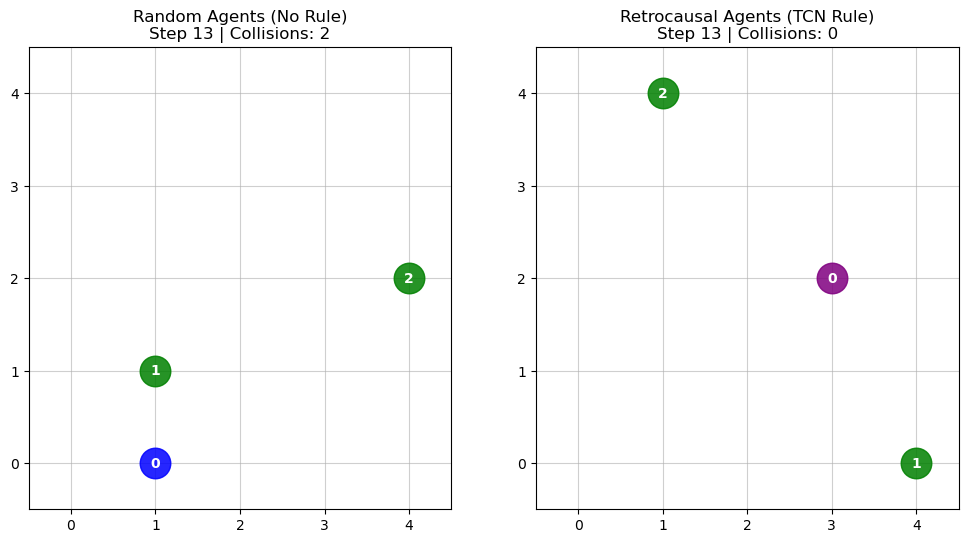

In [22]:
from src.visualize import create_animation
create_animation(steps=14)   # 跑 14 步让差异更明显

## 6. 进行分析

In [24]:
# ==============================================
# 正确 reload evaluate.py
# ==============================================
import importlib
import sys

# 确保 src 包被正确识别
if 'src' not in sys.modules:
    import src
    importlib.reload(src)   # reload 包

# 正确 reload evaluate 模块
importlib.reload(sys.modules['src.evaluate']) if 'src.evaluate' in sys.modules else None

from src.evaluate import run_analysis, compare_collision_reduction

print("✅ src.evaluate 已成功加载/重载")

# 运行深度分析
run_analysis()

# 可选：同时运行碰撞对比
# compare_collision_reduction(num_sims=100, steps=STEPS, tcn_path="models/tcn_best.pt")

⚠️ evaluate.py 已强制使用 CPU | device = cpu
✅ src.evaluate 已成功加载/重载
=== DEEP MODEL ANALYSIS (Retrocausal TCN) ===
使用设备: cpu

Processing 1200 runs for Agent 0...
Generated 2400 training sequences from Agent 0 (total_sequences=2400)
加载数据完成: (2400, 5, 12) sequences, 正样本率 0.0938
✅ 模型加载成功: E:\projects\Dynamic-Retrocausal-Simulator\models\tcn_best.pt

[Baseline] Accuracy: 0.6233 | Loss: 0.8909

--- 1. Failure Mode Analysis (Confusion Matrix) ---
True Negatives  (Safe → Safe)     : 1306
False Positives (Safe → Collision): 869 (Paranoia)
False Negatives (Collision → Safe): 35 (DANGEROUS - Blind Spot)
True Positives  (Collision → Collision): 190

--- 2. Feature Importance (Permutation) ---
Rel Pos 2   : 0.0721 impact
Rel Pos 0   : 0.0704 impact
Rel Pos 1   : 0.0700 impact
Rel Pos 3   : 0.0683 impact
Rel Pos 4   : 0.0000 impact
Rel Pos 5   : 0.0000 impact
Rel Pos 6   : 0.0000 impact
Rel Pos 7   : 0.0000 impact

--- 3. Temporal Ablation (History Matters?) ---
Only Last Step (No History) : 0.6233 (Dro